In [7]:
# Import Required Libraries
import os
import csv
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Install Required Packages (if needed)
import subprocess
import sys

packages = [
    'ultralytics',
    'torch',
    'torchvision',
    'scikit-learn',
    'opencv-python',
    'pandas',
    'numpy',
    'matplotlib',
    'tqdm'
]

print("Checking and installing required packages...")
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed")

Checking and installing required packages...
✓ ultralytics already installed
✓ torch already installed
✓ torchvision already installed
Installing scikit-learn...
✓ scikit-learn installed
Installing opencv-python...
✓ opencv-python installed
✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ tqdm already installed


In [9]:
# Load YOLO Model and Setup Paths
from ultralytics import YOLO

# Setup paths for Kaggle environment
#base_path = Path('/kaggle/input/happy-whale-and-dolphin')
base_path = Path('D:\Documents\School\\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale')
train_images_path = base_path / 'train_images'
test_images_path  = base_path / 'test_images'
train_csv_path    = base_path / 'train.csv'
#working_dir       = Path('/kaggle/working')
working_dir       = base_path / 'working'

print(f'Base path:         {base_path}')
print(f'Train images exist: {train_images_path.exists()}')
print(f'Test images exist:  {test_images_path.exists()}')
print(f'Train CSV exists:   {train_csv_path.exists()}')

# Load YOLO model for instance segmentation
try:
    model = YOLO('yolov8m-seg.pt')  # Medium model for better accuracy
    print('✓ YOLO model loaded successfully')
except Exception as e:
    print(f'Note: {e}')
    print('Model will be downloaded on first use')
    model = YOLO('yolov8m-seg.pt')


Base path:         D:\Documents\School\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale
Train images exist: True
Test images exist:  True
Train CSV exists:   True
✓ YOLO model loaded successfully


In [10]:
# Load Training Data
if not train_csv_path.exists():
    print(f"Error: Train CSV file not found at {train_csv_path}")
    print("Please ensure the 'train.csv' file exists in the workspace root directory.")
    raise FileNotFoundError(f"File not found: {train_csv_path}")

train_data = pd.read_csv(train_csv_path)
print(f"Total training samples: {len(train_data)}")
print(train_data.head())

# Get unique whale IDs
unique_ids = train_data['individual_id'].unique()
print(f"\nTotal unique whale IDs: {len(unique_ids)}")
print(f"Sample whale IDs: {unique_ids[:10]}")

# Create mapping from whale ID to images
whale_id_to_images = defaultdict(list)
for idx, row in train_data.iterrows():
    whale_id_to_images[row['individual_id']].append(row['image'])

# Get images per whale statistics
samples_per_whale = [len(images) for images in whale_id_to_images.values()]
print(f"\nImages per whale - Min: {min(samples_per_whale)}, Max: {max(samples_per_whale)}, Mean: {np.mean(samples_per_whale):.2f}")

Total training samples: 51033
                image             species individual_id
0  00021adfb725ed.jpg  melon_headed_whale  cadddb1636b9
1  000562241d384d.jpg      humpback_whale  1a71fbb72250
2  0007c33415ce37.jpg  false_killer_whale  60008f293a2b
3  0007d9bca26a99.jpg  bottlenose_dolphin  4b00fe572063
4  00087baf5cef7a.jpg      humpback_whale  8e5253662392

Total unique whale IDs: 15587
Sample whale IDs: <StringArray>
['cadddb1636b9', '1a71fbb72250', '60008f293a2b', '4b00fe572063',
 '8e5253662392', 'b9907151f66e', 'afb9b3978217', '444d8894ccc8',
 'df94b15285b9', 'b11b2404c7e3']
Length: 10, dtype: str

Images per whale - Min: 1, Max: 400, Mean: 3.27


In [11]:
# Fin Segmentation and Cropping Utilities
def segment_fins(image_path, model, confidence=0.5):
    """
    Segment fins from an image using YOLO
    Returns: image, masks, detection results
    """
    try:
        image = cv2.imread(str(image_path))
        if image is None:
            return None, None, None
        
        # Run YOLO segmentation
        results = model.predict(image, conf=confidence, verbose=False)
        
        return image, results, True
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None, None, None

def extract_fin_region(image, results, padding=20):
    """
    Extract fin region from image and masks
    Returns: cropped fin image, mask
    """
    if not results or len(results) == 0:
        return None, None
    
    result = results[0]
    
    # Check if segmentation masks exist
    if result.masks is None or len(result.masks) == 0:
        return None, None
    
    # Get the largest mask (likely the whale fin)
    masks = result.masks.data.cpu().numpy()
    if len(masks) == 0:
        return None, None
    
    # Use the mask with the largest area (assuming the fin is the largest object)
    mask_areas = [np.sum(m) for m in masks]
    largest_mask_idx = np.argmax(mask_areas)
    fin_mask = masks[largest_mask_idx]
    
    # Ensure mask is the same size as the image
    if fin_mask.shape != (image.shape[0], image.shape[1]):
        fin_mask = cv2.resize(fin_mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # Convert mask to binary 0-255
    fin_mask = (fin_mask * 255).astype(np.uint8)
    
    # Find bounding box of the mask
    contours, _ = cv2.findContours(fin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None, None
    
    # Get bounding rectangle
    x, y, w, h = cv2.boundingRect(np.vstack(contours))
    
    # Add padding
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(image.shape[1] - x, w + 2 * padding)
    h = min(image.shape[0] - y, h + 2 * padding)
    
    # Check if dimensions are valid
    if w <= 0 or h <= 0:
        return None, None
    
    # Crop image and mask
    cropped_image = image[y:y+h, x:x+w]
    cropped_mask = fin_mask[y:y+h, x:x+w]
    
    # Ensure arrays are contiguous and correct type
    cropped_image = np.ascontiguousarray(cropped_image.astype(np.uint8))
    cropped_mask = np.ascontiguousarray(cropped_mask.astype(np.uint8))
    
    # Apply mask to image (keep only fin region)
    masked_image = cv2.bitwise_and(cropped_image, cropped_image, mask=cropped_mask)
    
    return masked_image, cropped_mask

print("✓ Fin segmentation utilities defined")

✓ Fin segmentation utilities defined


In [12]:
# Process Training Images and Extract Fins
# Create output directories
fin_crops_dir = working_dir / 'fin_crops'
fin_crops_dir.mkdir(exist_ok=True)

# Extract fins from training images
fin_data = []
processed_count = 0
failed_count = 0

print("Processing training images to extract fins...")
for idx, row in tqdm(train_data.iterrows(), total=len(train_data)):
    image_name = row['image']
    whale_id = row['individual_id']
    image_path = train_images_path / image_name
    
    if not image_path.exists():
        failed_count += 1
        continue
    
    # Segment fins
    image, results, success = segment_fins(str(image_path), model)
    
    if success and image is not None and results is not None:
        # Extract fin region
        fin_image, fin_mask = extract_fin_region(image, results)
        
        if fin_image is not None and fin_mask is not None:
            # Save fin crop
            fin_crop_name = f"{whale_id}_{image_name.split('.')[0]}_fin.jpg"
            fin_crop_path = fin_crops_dir / fin_crop_name
            cv2.imwrite(str(fin_crop_path), fin_image)
            
            fin_data.append({
                'original_image': image_name,
                'fin_crop': fin_crop_name,
                'whale_id': whale_id,
                'species': row['species']
            })
            processed_count += 1
        else:
            failed_count += 1
    else:
        failed_count += 1

fin_df = pd.DataFrame(fin_data)
print(f"\n✓ Successfully processed {processed_count} images")
print(f"✗ Failed to extract fins from {failed_count} images")
print(f"Fin crops saved to: {fin_crops_dir}")
print(f"Total fin crops: {len(fin_df)}")

Processing training images to extract fins...


100%|██████████| 51033/51033 [59:16<00:00, 14.35it/s]  


✓ Successfully processed 17197 images
✗ Failed to extract fins from 33836 images
Fin crops saved to: D:\Documents\School\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale\working\fin_crops
Total fin crops: 17197


In [13]:
# ArcFace Model Setup
# We'll use a pre-trained face recognition model and fine-tune it for whale fins

from torchvision.models import resnet50
from torch.nn import Sequential, Linear, ReLU, Dropout
import torch.nn.functional as F

class ArcFaceModel(nn.Module):
    """
    ArcFace model for whale fin identification
    Uses ResNet50 backbone with ArcFace loss
    """
    def __init__(self, num_classes, embedding_size=512, backbone='resnet50'):
        super(ArcFaceModel, self).__init__()
        
        # Backbone
        if backbone == 'resnet50':
            resnet = resnet50(weights='IMAGENET1K_V1')
            self.backbone = nn.Sequential(*list(resnet.children())[:-1])
            backbone_out_features = 2048
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        
        # Embedding layer
        self.embedding = nn.Linear(backbone_out_features, embedding_size)
        self.embedding_bn = nn.BatchNorm1d(embedding_size)
        
        # Classification layer (for training)
        self.classifier = nn.Linear(embedding_size, num_classes)
        
        self.embedding_size = embedding_size
        self.num_classes = num_classes
    
    def forward(self, x, return_embedding=False):
        # Backbone
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        
        # Embedding
        embedding = self.embedding(x)
        embedding = self.embedding_bn(embedding)
        embedding = F.normalize(embedding, p=2, dim=1)
        
        if return_embedding:
            return embedding
        
        # Classification
        logits = self.classifier(embedding)
        return logits, embedding

# Get number of unique whale IDs
num_whale_ids = len(unique_ids)
print(f"Number of whale IDs for training: {num_whale_ids}")

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_arcface = ArcFaceModel(num_classes=num_whale_ids, embedding_size=512)
model_arcface = model_arcface.to(device)

print("✓ ArcFace model initialized")

Number of whale IDs for training: 15587
Using device: cuda
✓ ArcFace model initialized


In [14]:
# Create Dataset and DataLoader for Training
class FinDataset(Dataset):
    """Dataset for whale fin images"""
    def __init__(self, fin_df, fin_crops_dir, whale_id_to_idx, transform=None):
        self.fin_df = fin_df.reset_index(drop=True)
        self.fin_crops_dir = fin_crops_dir
        self.whale_id_to_idx = whale_id_to_idx
        self.transform = transform
    
    def __len__(self):
        return len(self.fin_df)
    
    def __getitem__(self, idx):
        row = self.fin_df.iloc[idx]
        fin_crop_path = self.fin_crops_dir / row['fin_crop']
        
        # Read image
        image = cv2.imread(str(fin_crop_path))
        if image is None:
            # Return a zero tensor if image can't be read
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            # Resize to 224x224
            image = cv2.resize(image, (224, 224))
        
        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        else:
            # Default transform
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        # Get label
        whale_id = row['whale_id']
        label = self.whale_id_to_idx[whale_id]
        
        return image, label

# Create whale ID to index mapping
whale_id_to_idx = {whale_id: idx for idx, whale_id in enumerate(unique_ids)}
idx_to_whale_id = {idx: whale_id for whale_id, idx in whale_id_to_idx.items()}

print(f"Created mapping for {len(whale_id_to_idx)} whale IDs")

# Data augmentation transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create dataset
fin_dataset = FinDataset(fin_df, fin_crops_dir, whale_id_to_idx, transform=None)
batch_size = 32
train_loader = DataLoader(fin_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"✓ Dataset created with {len(fin_dataset)} samples")
print(f"✓ DataLoader created with batch size {batch_size}")

Created mapping for 15587 whale IDs
✓ Dataset created with 17197 samples
✓ DataLoader created with batch size 32


In [15]:
# ArcFace Loss Function
class ArcFaceLoss(nn.Module):
    """ArcFace loss for metric learning"""
    def __init__(self, embedding_size=512, num_classes=None, margin=0.5, scale=64):
        super(ArcFaceLoss, self).__init__()
        self.margin = margin
        self.scale = scale
        self.embedding_size = embedding_size
        self.num_classes = num_classes
        
        # Weight initialization - W should be (num_classes, embedding_size)
        self.W = nn.Parameter(torch.randn(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: normalized embeddings (batch_size, embedding_size)
            labels: class labels (batch_size,)
        """
        # Normalize weights along the embedding dimension (dim=1)
        W = F.normalize(self.W, p=2, dim=1)
        
        # Compute cosine similarity
        cos_theta = F.linear(embeddings, W)
        cos_theta = torch.clamp(cos_theta, -1 + 1e-7, 1 - 1e-7)
        
        # Compute angle
        theta = torch.acos(cos_theta)
        
        # Apply margin
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        
        # ArcFace margin
        theta_m = theta + self.margin * one_hot
        cos_theta_m = torch.cos(theta_m)
        
        # Scale and compute loss
        logits = self.scale * cos_theta_m
        loss = F.cross_entropy(logits, labels)
        
        return loss

# Initialize loss function
arcface_loss = ArcFaceLoss(embedding_size=512, num_classes=num_whale_ids)
arcface_loss = arcface_loss.to(device)

print("✓ ArcFace loss function initialized")

✓ ArcFace loss function initialized


In [16]:
# Training Function
def train_arcface(model, arcface_loss, train_loader, num_epochs=10, learning_rate=0.001):
    """Train ArcFace model"""
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(arcface_loss.parameters()),
        lr=learning_rate
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    
    model.train()
    training_loss = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        num_batches = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            _, embeddings = model(images)
            loss = arcface_loss(embeddings, labels)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_epoch_loss = epoch_loss / num_batches
        training_loss.append(avg_epoch_loss)
        scheduler.step()
        
        print(f"Epoch {epoch+1} - Average Loss: {avg_epoch_loss:.4f}")
    
    return training_loss

# Train the model (note: this may take a while)
print("Starting ArcFace training...")
print(f"Total batches per epoch: {len(train_loader)}")
print(f"Training samples: {len(fin_dataset)}")

num_epochs = 5  # Reduce for faster training; increase for better results
training_losses = train_arcface(model_arcface, arcface_loss, train_loader, 
                                num_epochs=num_epochs, learning_rate=0.001)

print("✓ Training completed")

Starting ArcFace training...
Total batches per epoch: 538
Training samples: 17197


Epoch 1/5: 100%|██████████| 538/538 [09:55<00:00,  1.11s/it, loss=39.1829]


Epoch 1 - Average Loss: 42.7092


Epoch 2/5: 100%|██████████| 538/538 [03:32<00:00,  2.53it/s, loss=11.8766]


Epoch 2 - Average Loss: 23.5252


...

Epoch 3 - Average Loss: 6.4008


Epoch 4/5: 100%|██████████| 538/538 [03:31<00:00,  2.55it/s, loss=6.2794] 


Epoch 4 - Average Loss: 5.8207


Epoch 5/5: 100%|██████████| 538/538 [03:30<00:00,  2.55it/s, loss=5.8495] 

Epoch 5 - Average Loss: 7.4391
✓ Training completed


In [17]:
# Inference and Whale Matching Functions
def get_embedding(image_path, model, device):
    """Get embedding for an image"""
    image = cv2.imread(str(image_path))
    if image is None:
        return None
    
    image = cv2.resize(image, (224, 224))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
    
    # Normalize
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    image = normalize(image)
    
    image = image.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        embedding = model(image, return_embedding=True)
    
    return embedding.cpu().numpy()[0]

def build_embedding_index(fin_df, fin_crops_dir, model, device):
    """Build embedding index for all training fins"""
    embeddings = []
    whale_ids = []
    fin_crops = []
    
    print("Building embedding index...")
    for idx, row in tqdm(fin_df.iterrows(), total=len(fin_df)):
        fin_crop_path = fin_crops_dir / row['fin_crop']
        embedding = get_embedding(fin_crop_path, model, device)
        
        if embedding is not None:
            embeddings.append(embedding)
            whale_ids.append(row['whale_id'])
            fin_crops.append(row['fin_crop'])
    
    embeddings = np.array(embeddings)
    embeddings = normalize(embeddings, axis=1, norm='l2')
    
    return embeddings, whale_ids, fin_crops

# Build index
embedding_index, index_whale_ids, index_fin_crops = build_embedding_index(
    fin_df, fin_crops_dir, model_arcface, device
)

print(f"✓ Built embedding index with {len(embedding_index)} samples")

Building embedding index...


100%|██████████| 17197/17197 [03:56<00:00, 72.59it/s]


✓ Built embedding index with 17197 samples


In [18]:
# Whale Identification and Matching
def identify_whale(image_path, model, embedding_index, index_whale_ids,
                   similarity_threshold=0.75, top_k=5):
    """
    Identify whale from fin image.
    Returns a space-separated string of up to 5 individual_id predictions
    (MAP@5 format required by competition).
    """
    query_embedding = get_embedding(image_path, model, device)
    if query_embedding is None:
        return f'new_individual ' * top_k, 0, []

    query_embedding = normalize(query_embedding.reshape(1, -1), axis=1, norm='l2')[0]
    similarities = embedding_index @ query_embedding
    top_indices = np.argsort(similarities)[::-1][:top_k]

    top_matches = []
    seen_ids = set()
    ranked_ids = []

    for idx in top_indices:
        wid  = index_whale_ids[idx]
        sim  = float(similarities[idx])
        top_matches.append({'whale_id': wid, 'similarity': sim,
                            'fin_crop': index_fin_crops[idx]})
        if wid not in seen_ids:
            ranked_ids.append(wid)
            seen_ids.add(wid)

    # If the best match is below threshold, push 'new_individual' to front
    best_sim = float(similarities[top_indices[0]])
    if best_sim < similarity_threshold and 'new_individual' not in ranked_ids:
        ranked_ids.insert(0, 'new_individual')
    elif 'new_individual' not in ranked_ids:
        # always include new_individual as a fallback candidate
        ranked_ids.append('new_individual')

    # Truncate / pad to exactly top_k predictions
    ranked_ids = ranked_ids[:top_k]
    predictions_str = ' '.join(ranked_ids)

    return predictions_str, best_sim, top_matches


def process_test_images(test_images_dir, model, embedding_index, index_whale_ids,
                        similarity_threshold=0.75):
    """Process all test images and return MAP@5 formatted predictions."""
    results = []

    if not test_images_dir.exists():
        print(f'Test images directory not found: {test_images_dir}')
        return results

    test_images = sorted(
        list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png'))
    )

    if not test_images:
        print(f'No test images found in {test_images_dir}')
        return results

    print(f'Processing {len(test_images)} test images...')

    for test_image_path in tqdm(test_images):
        image, seg_results, success = segment_fins(str(test_image_path), model)

        predictions_str = 'new_individual'  # safe default
        confidence      = 0.0
        top_matches     = []

        if success and image is not None and seg_results is not None:
            fin_image, fin_mask = extract_fin_region(image, seg_results)
            if fin_image is not None:
                temp_fin_path = working_dir / f'fin_crops/temp_{test_image_path.name}'
                cv2.imwrite(str(temp_fin_path), fin_image)
                predictions_str, confidence, top_matches = identify_whale(
                    temp_fin_path, model_arcface, embedding_index, index_whale_ids,
                    similarity_threshold=similarity_threshold
                )
                temp_fin_path.unlink(missing_ok=True)

        results.append({
            'image':       test_image_path.name,
            'predictions': predictions_str,
            'confidence':  confidence,
        })

    return results

print('✓ Whale identification functions defined')


✓ Whale identification functions defined


In [19]:
# Process Test Images and Generate Submission (MAP@5 format)
print('Processing test images...')
test_predictions = process_test_images(
    test_images_path,
    model,
    embedding_index,
    index_whale_ids,
    similarity_threshold=0.75
)

predictions_df = pd.DataFrame(test_predictions)
print(f'\n✓ Processed {len(predictions_df)} test images')

if len(predictions_df) > 0:
    print('\nSample predictions (MAP@5 format):')
    print(predictions_df[['image', 'predictions']].head(10))

# ── Save submission in the competition-required format ──────────────────────
# Columns: image | predictions  (space-separated list of up to 5 individual_ids)
submission_path = working_dir / 'submission.csv'
predictions_df[['image', 'predictions']].to_csv(submission_path, index=False)
print(f'\n✓ Submission saved to {submission_path}')
print('   Columns: image, predictions  (MAP@5 – up to 5 space-separated individual_ids)')


Processing test images...
Processing 27956 test images...


100%|██████████| 27956/27956 [1:00:23<00:00,  7.72it/s]   



✓ Processed 27956 test images

Sample predictions (MAP@5 format):
                image                                        predictions
0  000110707af0ba.jpg                                     new_individual
1  0006287ec424cb.jpg                                     new_individual
2  000809ecb2ccad.jpg                                     new_individual
3  00098d1376dab2.jpg                                     new_individual
4  000b8d89c738bd.jpg                                     new_individual
5  000e246888710c.jpg                                     new_individual
6  000eb6e73a31a5.jpg                                     new_individual
7  000fe6ebfc9893.jpg                                     new_individual
8  0011f7a65044e4.jpg  77410a623426 15d96d5d42c2 be2aa86d0e5b 1f1913e...
9  0012ff300032e3.jpg                                     new_individual

✓ Submission saved to D:\Documents\School\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale\working\submission.csv
   

Visualizing fin extraction samples...


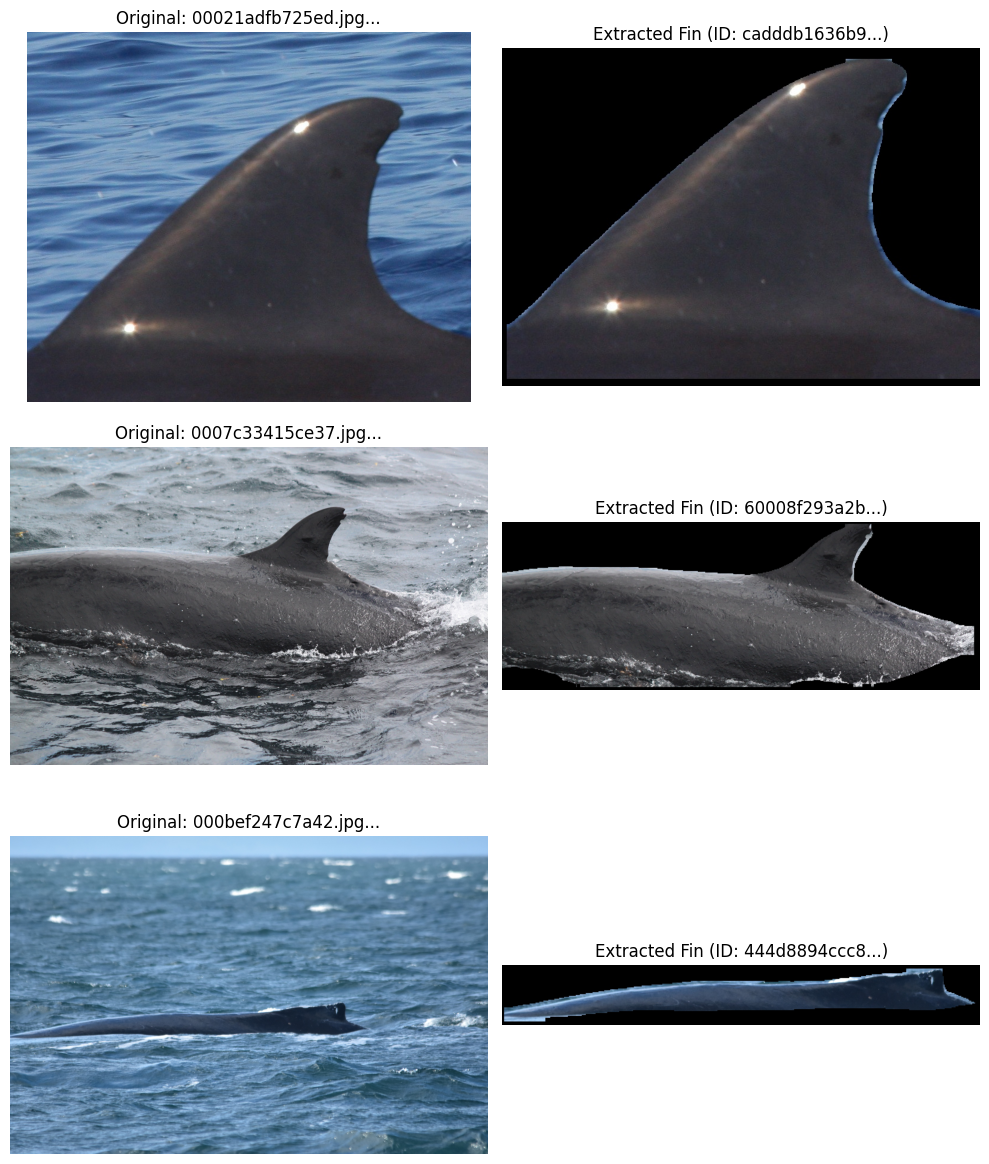

In [20]:
# Visualization and Analysis
def visualize_fin_extraction(image_name, num_samples=5):
    """Visualize fin extraction for sample training images"""
    sample_images = train_data[train_data['image'].isin(
        fin_df['original_image'].unique()
    )].head(num_samples)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4*num_samples))
    
    for idx, (_, row) in enumerate(sample_images.iterrows()):
        image_name = row['image']
        image_path = train_images_path / image_name
        
        if not image_path.exists():
            continue
        
        # Original image
        image = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        axes[idx, 0].imshow(image_rgb)
        axes[idx, 0].set_title(f"Original: {image_name[:30]}...")
        axes[idx, 0].axis('off')
        
        # Find corresponding fin crop
        fin_crops = fin_df[fin_df['original_image'] == image_name]
        if len(fin_crops) > 0:
            fin_crop_name = fin_crops.iloc[0]['fin_crop']
            fin_crop_path = fin_crops_dir / fin_crop_name
            if fin_crop_path.exists():
                fin_image = cv2.imread(str(fin_crop_path))
                fin_image_rgb = cv2.cvtColor(fin_image, cv2.COLOR_BGR2RGB)
                axes[idx, 1].imshow(fin_image_rgb)
                axes[idx, 1].set_title(f"Extracted Fin (ID: {fin_crops.iloc[0]['whale_id'][:15]}...)")
                axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize sample fin extractions
print("Visualizing fin extraction samples...")
visualize_fin_extraction("", num_samples=3)

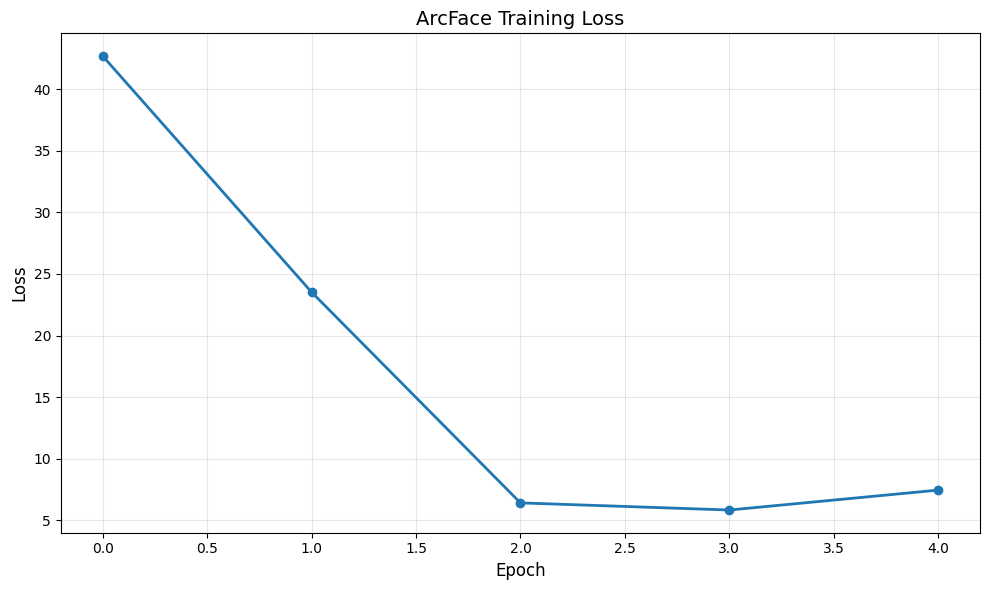

Initial loss: 42.7092
Final loss: 7.4391
Loss reduction: 82.58%


In [21]:
# Plot Training Loss
plt.figure(figsize=(10, 6))
plt.plot(training_losses, marker='o', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('ArcFace Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {training_losses[0]:.4f}")
print(f"Final loss: {training_losses[-1]:.4f}")
print(f"Loss reduction: {(training_losses[0] - training_losses[-1])/training_losses[0]*100:.2f}%")

In [23]:
# Save Model and Metadata
model_save_path = working_dir / 'arcface_model.pth'
metadata_save_path = working_dir / 'model_metadata.pth'

# Save model
torch.save(model_arcface.state_dict(), model_save_path)
print(f"✓ Model saved to {model_save_path}")

# Save metadata
metadata = {
    'embedding_size': 512,
    'num_classes': num_whale_ids,
    'whale_id_to_idx': whale_id_to_idx,
    'idx_to_whale_id': idx_to_whale_id,
    'embedding_index': embedding_index,
    'index_whale_ids': index_whale_ids
}
torch.save(metadata, metadata_save_path)
print(f"✓ Metadata saved to {metadata_save_path}")

# Summary
print("\n" + "="*70)
print("WHALE FIN IDENTIFICATION PIPELINE SUMMARY")
print("="*70)
print(f"✓ YOLO model: YOLOv8m-seg (fin segmentation)")
print(f"✓ Backbone: ResNet50 (ArcFace)")
print(f"✓ Embedding size: 512")
print(f"✓ Training samples: {len(fin_dataset)}")
print(f"✓ Unique whale IDs: {num_whale_ids}")
print(f"✓ Training epochs: {num_epochs}")
print(f"✓ Final training loss: {training_losses[-1]:.4f}")
print(f"✓ Test images processed: {len(predictions_df)}")
print(f"  - Identified whales: {predictions_df['predictions'].apply(lambda x: x.split()[0] != 'new_individual').sum()}")
print(f"  - New individuals: {predictions_df['predictions'].apply(lambda x: x.split()[0] == 'new_individual').sum()}")
print("\nOutput files:")
print(f"  - Submission:  submission.csv  (MAP@5 format)")
print(f"  - Model weights: arcface_model.pth")
print(f"  - Metadata: model_metadata.pth")
print(f"  - Fin crops: fin_crops/ directory")
print("="*70)

✓ Model saved to D:\Documents\School\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale\working\arcface_model.pth
✓ Metadata saved to D:\Documents\School\2026\Spring 2026\COMP 5230\hw\Project\comp-vision-happywhale\working\model_metadata.pth

WHALE FIN IDENTIFICATION PIPELINE SUMMARY
✓ YOLO model: YOLOv8m-seg (fin segmentation)
✓ Backbone: ResNet50 (ArcFace)
✓ Embedding size: 512
✓ Training samples: 17197
✓ Unique whale IDs: 15587
✓ Training epochs: 5
✓ Final training loss: 7.4391
✓ Test images processed: 27956
  - Identified whales: 10510
  - New individuals: 17446

Output files:
  - Submission:  submission.csv  (MAP@5 format)
  - Model weights: arcface_model.pth
  - Metadata: model_metadata.pth
  - Fin crops: fin_crops/ directory


In [24]:
# Helper Functions for Future Use
def load_model_and_metadata(model_path, metadata_path, device):
    """Load trained model and metadata"""
    # Load metadata
    metadata = torch.load(metadata_path, map_location='cpu')
    
    # Create model
    model = ArcFaceModel(
        num_classes=metadata['num_classes'],
        embedding_size=metadata['embedding_size']
    )
    
    # Load weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    return model, metadata

def identify_single_image(image_path, model, metadata, device, 
                          similarity_threshold=0.75):
    """Identify whale in a single image"""
    from sklearn.preprocessing import normalize
    
    # Get embedding
    query_embedding = get_embedding(image_path, model, device)
    if query_embedding is None:
        return None, 0, []
    
    # Normalize
    query_embedding = normalize(query_embedding.reshape(1, -1), axis=1, norm='l2')[0]
    
    # Compute similarities
    embedding_index = metadata['embedding_index']
    index_whale_ids = metadata['index_whale_ids']
    similarities = embedding_index @ query_embedding
    
    # Get top matches
    top_indices = np.argsort(similarities)[::-1][:5]
    top_matches = []
    
    for idx in top_indices:
        top_matches.append({
            'whale_id': index_whale_ids[idx],
            'similarity': float(similarities[idx])
        })
    
    # Determine result
    best_similarity = similarities[top_indices[0]]
    best_whale_id = index_whale_ids[top_indices[0]]
    
    if best_similarity >= similarity_threshold:
        return best_whale_id, best_similarity, top_matches
    else:
        return "new_individual", best_similarity, top_matches

print("✓ Helper functions defined for future model usage")
print("\nTo load the model in the future, use:")
print("  model, metadata = load_model_and_metadata(")
print("      'arcface_model.pth',")
print("      'model_metadata.pth',")
print("      device")
print("  )")
print("\nTo identify a whale in a new image:")
print("  whale_id, confidence, matches = identify_single_image(")
print("      'path/to/image.jpg',")
print("      model,")
print("      metadata,")
print("      device,")
print("      similarity_threshold=0.75")
print("  )")

✓ Helper functions defined for future model usage

To load the model in the future, use:
  model, metadata = load_model_and_metadata(
      'arcface_model.pth',
      'model_metadata.pth',
      device
  )

To identify a whale in a new image:
  whale_id, confidence, matches = identify_single_image(
      'path/to/image.jpg',
      model,
      metadata,
      device,
      similarity_threshold=0.75
  )
